In [1]:
import numpy as np
from sklearn.datasets import make_classification

X,y = make_classification(n_samples=30, n_features=2, n_classes=2, n_informative=2, n_redundant=0, n_repeated=0, shuffle=False)

X = np.absolute(X)

X = np.round(X, 2) * 100

X = X.astype(int)

print(X)
print(y)

[[ 77  98]
 [ 70  85]
 [242 244]
 [ 40  21]
 [ 71  65]
 [ 74  91]
 [ 30  22]
 [ 77  79]
 [131  26]
 [106  25]
 [ 99  37]
 [ 78 163]
 [113  92]
 [164 119]
 [137  89]
 [ 90 190]
 [ 81  95]
 [ 85 123]
 [  4 252]
 [146  96]
 [132 129]
 [ 30 195]
 [ 30 250]
 [160  95]
 [ 80 104]
 [ 63 100]
 [145 110]
 [111  80]
 [ 76  76]
 [118 150]]
[0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 1 1 1 1 1 1 1]


In [3]:
import pandas as pd

y_new = y.reshape(len(y), 1)

data = np.concatenate((X, y_new), axis=1)

nama_kolom = ['Feature 1', 'Feature 2', 'Label']

df = pd.DataFrame(data, columns=nama_kolom)

df.head()

,Feature 1,Feature 2,Label
0,77,98,0
1,70,85,0
2,242,244,0
3,40,21,0
4,71,65,0


In [6]:
labels = {
    1 : 'Class A',
    0 : 'Class B'
}

df_label = df.copy()

df_label['Label'] = df_label['Label'].map(labels)

df_label.head()

,Feature 1,Feature 2,Label
0,77,98,Class B
1,70,85,Class B
2,242,244,Class B
3,40,21,Class B
4,71,65,Class B


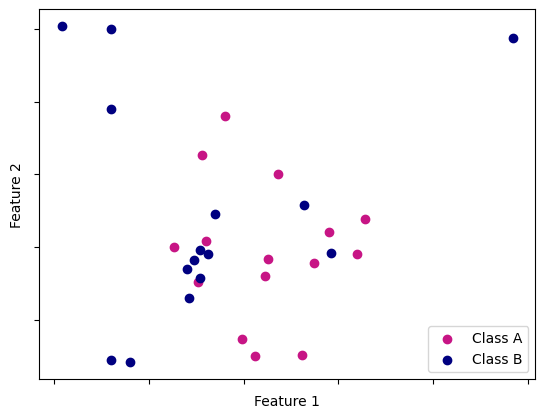

In [9]:
import matplotlib.pyplot as plt

colors = {
    'Class A': 'MediumVioletRed',
    'Class B': 'Navy'
}

gb = df_label.groupby('Label')

class_a = gb.get_group('Class A')
class_b = gb.get_group('Class B')

plt.scatter(
    x=class_a['Feature 1'],
    y=class_a['Feature 2'],
    c=colors['Class A']
)

plt.scatter(
    x=class_b['Feature 1'],
    y=class_b['Feature 2'],
    c=colors['Class B']
)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.legend(['Class A', 'Class B'])

plt.gca().axes.xaxis.set_ticklabels([])
plt.gca().axes.yaxis.set_ticklabels([])

plt.show()

In [10]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

mnb = MultinomialNB()

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=30)

mnb.fit(X_train, y_train)

y_train_pred = mnb.predict(X_train)

acc_train = accuracy_score(y_train, y_train_pred)

y_test_pred = mnb.predict(X_test)

acc_test = accuracy_score(y_test, y_test_pred)

print(f'Training accuracy: {acc_train}')
print(f'Test accuracy: {acc_test}')

Training accuracy: 0.6190476190476191
Test accuracy: 0.5555555555555556


In [11]:
from sklearn.naive_bayes import GaussianNB 

gnb = GaussianNB()

gnb.fit(X_train, y_train)

y_train_pred_gnb = gnb.predict(X_train)

acc_train_gnb = accuracy_score(y_train, y_train_pred_gnb)

y_test_pred_gnb = gnb.predict(X_test)

acc_test_gnb = accuracy_score(y_test, y_test_pred_gnb)

print(f'Training accuracy (Gaussian): {acc_train_gnb}')
print(f'Test accuracy (Gaussian): {acc_test_gnb}')

Training accuracy (Gaussian): 0.8571428571428571
Test accuracy (Gaussian): 0.5555555555555556
